<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Binary Classification

Here, we use a tabular dataset from kaggle (https://www.kaggle.com/sammy123/lower-back-pain-symptoms-dataset) with features on patients physical spine details possibly suited for classifying whether the person is 'abnormal' or 'normal' - possibly suffers back pain or not.   

We here just want to see how the training works with logistic regression (binary case). We set aside a proper handling of the learning experiment by splitting the data into a train and test partition (in general we would even have a validation partition). We focus here on making the system learn something.

1. Download the dataset from kaggle (see the link in the notebook). Load it into a pandas dataframe (see the code in the notebook). Normalise the data.
2. Complete the code for the implementation of the methods \verb|predict|, \verb|cost|, \verb|gradient_cost|, \verb|accuracy|. As a test, just invoke the method by suitable dummy values.
3. Implement (full) batch GD for minimizing the CE cost (without autograd). Plot cost vs the number of epochs.
4. Implement (full) batch GD for minimizing the CE cost, this time with autograd. show that you obtain consistent results.
5. Tune the learning rate. What is a reasonable learning rate?

### 1. Load Data

In [ ]:
import pandas as pd
df = pd.read_csv("Dataset_spine.xls")
df = df.drop(columns=['Unnamed: 13'])
N  = df.shape[0]
df.head()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,Col11,Col12,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0.744503,12.5661,14.5386,15.30468,-28.658501,43.5123,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal


#### Normalization and Turning into Torch Tensors

In [ ]:
x0 = torch.from_numpy(df.values[:,0:-1].astype(np.float64))
X = (x0-torch.mean(x0, dim=0))/torch.std(x0,dim=0)
Y = torch.tensor(('Abnormal'==df.values[:,-1])).int().reshape(-1,1)
print(X.shape, Y.shape)

torch.Size([310, 12]) torch.Size([310, 1])


### 2. Implement the Model for (Binary) Logistic Regression

Data:  $\,\qquad X = \left(\begin{array}{cccc} 1 & X_{11} & \dots & X_{1n} \\ \vdots & \vdots & \vdots & \vdots \\ 1 & X_{N1} & \dots & X_{Nn}\end{array}\right)\qquad$ and $\qquad Y = \left(\begin{array}{c} Y_{1} \\ \vdots \\ Y_{N} \end{array}\right)$

Model: $\qquad\hat{Y}(X;W) = \sigma\left(X W^\intercal\right) \qquad$ where $\qquad W = \left(\begin{array}{c} W_0 \\ W_1 \\ \vdots \\ W_n \end{array}\right)$

The model outputs the probability of observing in a sample $x$ a '1' (Abnormal).

Cost:  $\,\qquad C(W) = -\frac{1}{N}\sum_j \left(Y_j\log(\hat{Y}_j(X;W)) + (1-Y_j)\log(1-\hat{Y}_j(X;W))\right)$

__Remark:__ Note that the logarithm diverges at arguments approaching 0. Make sure that you don't run into numerical issues.

In [ ]:
# compose torch tensors X of shape (N,13) by inserting a column with 1's as first column
X = torch.cat((torch.ones(N,1),X), dim=1)

In [ ]:
# implement methods for predicting the probability of having label 0 or 1 (W with shape (1,13))
def predict(X,W):
    # YOUR CODE (START)
    return torch.sigmoid(X @ W.T)   # not the softmax with the logistic regression
    # YOUR CODE (END)

def cost(X,Y,W):
    # YOUR CODE (START)
    eps = 1e-10 # to prevent log(0)
    yhat = torch.clamp(predict(X, W), eps, 1 - eps)
    return (-1/N) * torch.sum(Y * torch.log(yhat) + (1 - Y) * torch.log(1 - yhat))
    # YOUR CODE (END)

In [ ]:
def gradient_cost(X,Y,W):
    # YOUR CODE (START)
    return ((predict(X, W) - Y).T@X)/N
    # YOUR CODE (END)

def accuracy(Y,Yhat):
    # YOUR CODE (START)
    m = 0
    for i in range (len(Y)):
        if Y[i] == torch.round(Yhat)[i] :
            m+=1
    return m/len(Y) *100
    # YOUR CODE (END)

Just for testing:

In [ ]:
W = torch.randn((1,13), dtype=torch.double)
print("prediction : ", predict(X[0],W))
print("cost : ", cost(X,Y,W))
print("gradient_cost : ", gradient_cost(X,Y,W))
print("accuracy (%) : ", accuracy(Y,predict(X,W)))

prediction :  tensor([0.0973], dtype=torch.float64)
cost :  tensor(1.1642, dtype=torch.float64)
gradient_cost :  tensor([[-0.3489, -0.2822, -0.2386, -0.2169, -0.1845,  0.1590, -0.2493,  0.0266,
          0.1342, -0.0529, -0.0810, -0.0686, -0.0306]], dtype=torch.float64)
accuracy (%) :  38.387096774193544


    38% isn't a good accuracy. The algorithme can be enchance.

### 3. Implement Full Batch Gradient Descent

Training Accuracy (max,end): 86.451613, 85.483871
Training Cost (end): 0.284130


Text(0.5, 1.0, 'Accuracy according the epoch')

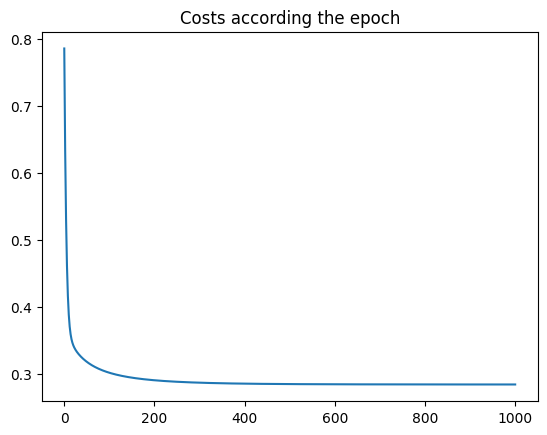

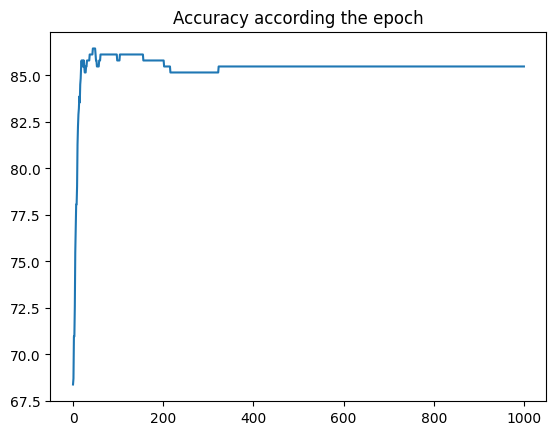

In [ ]:
# adjust if needed
nepochs = 1000
lr = 1.0

# initial parameter
W = torch.randn((1,13), dtype=torch.double)

# track the costs
costs = [cost(X,Y,W)]
accs = [accuracy(Y,predict(X,W))]

# YOUR CODE (START)
for epoch in range(nepochs):
    W = W - lr * gradient_cost(X, Y, W)
    costs.append(cost(X,Y,W))
    accs.append(accuracy(Y,predict(X,W)))
# YOUR CODE (END)

accs = np.array(accs)

print("Training Accuracy (max,end): %f, %f"%(np.max(accs), accs[-1]))
print("Training Cost (end): %f"%costs[-1].item())
plt.figure(1)
plt.plot(range(nepochs+1),costs)
plt.title("Costs according the epoch")
plt.figure(2)
plt.plot(range(nepochs+1),accs)
plt.title("Accuracy according the epoch")

    We can see that a high number of epoch enhance the accuracy (85% at the end), while the cost decreases. We have to choose carefully the batch size not to waste ressources of calculs but also to have a quality result, which converge. The parameter `nepoch` seems to be good, the learning rate is maybe too high though.

### 4. Implement Full Batch Gradient Descent with PyTorch's autograd

Training Accuracy (max,end): 86.774194, 85.483871
Training Cost (end): 0.284132


Text(0.5, 1.0, 'Accuracy according the epoch')

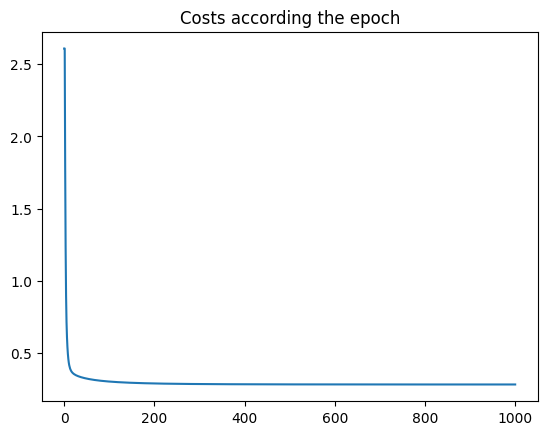

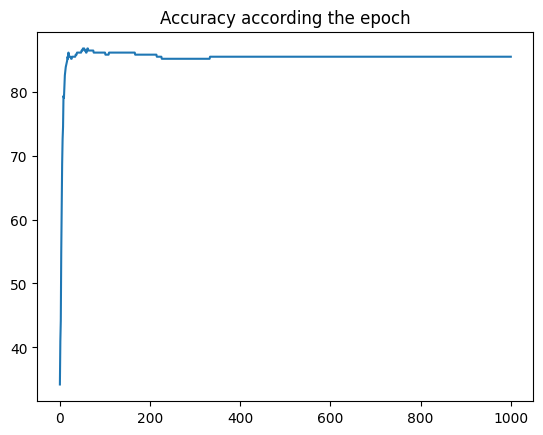

In [ ]:
nepochs = 1000
lr = 1.0

# initial parameter
W = torch.randn((1,13), dtype=torch.double).requires_grad_(True) # requires true for "autograd"

# track the costs
costs = [cost(X,Y,W).item()]
accs = [accuracy(Y,predict(X,W))]

# YOUR CODE (START)
for epoch in range(nepochs):
    c = cost(X,Y,W)
    costs.append(c.item())
    c.backward()
    with torch.no_grad():
        W -= lr * W.grad
    W.grad.zero_()
    accs.append(accuracy(Y,predict(X,W)))
# YOUR CODE (END)

accs = np.array(accs)

print("Training Accuracy (max,end): %f, %f"%(np.max(accs), accs[-1]))
print("Training Cost (end): %f"%costs[-1])
plt.figure(1)
plt.plot(range(nepochs+1),costs)
plt.title("Costs according the epoch")
plt.figure(2)
plt.plot(range(nepochs+1),accs)
plt.title("Accuracy according the epoch")

    We obtain similar results as before.

### 5. Tune Learning Rates

Play with different learning rates: Explore for what learning rates
- the learning is most efficient
- the learning yet works
- the learning does not work anymore (learning rate too large)

Explain the different scenarios.

    - First case : lr = 0.1

    The algorithm converges with a satisfying accuracy (85% at the end) and with a low cost (<0.4).

Training Accuracy (max,end): 86.774194, 86.451613
Training Cost (end): 0.311666


Text(0.5, 1.0, 'Accuracy according the epoch')

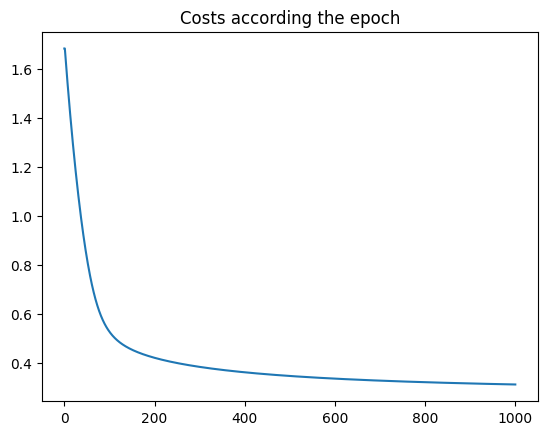

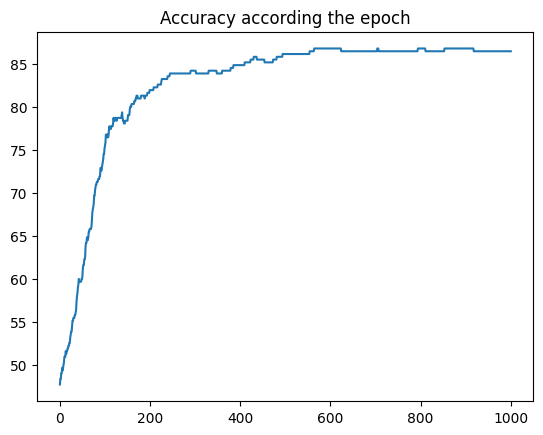

In [ ]:
nepochs = 1000  # no change
lr = 0.1

# initial parameter
W = torch.randn((1,13), dtype=torch.double).requires_grad_(True)

# track the costs
costs = [cost(X,Y,W).item()]
accs = [accuracy(Y,predict(X,W))]

# YOUR CODE (START)
for epoch in range(nepochs):
    c = cost(X,Y,W)
    costs.append(c.item())
    c.backward()
    with torch.no_grad():
        W -= lr * W.grad
    W.grad.zero_()
    accs.append(accuracy(Y,predict(X,W)))
# YOUR CODE (END)

accs = np.array(accs)

print("Training Accuracy (max,end): %f, %f"%(np.max(accs), accs[-1]))
print("Training Cost (end): %f"%costs[-1])
plt.figure(1)
plt.plot(range(nepochs+1),costs)
plt.title("Costs according the epoch")
plt.figure(2)
plt.plot(range(nepochs+1),accs)
plt.title("Accuracy according the epoch")

    - Second case : lr = 0.01

    The learning rate is too low, for sure. We can see that the accuracy is struggling to increase while the cost needs time to decrease.

Training Accuracy (max,end): 78.064516, 77.419355
Training Cost (end): 0.458493


Text(0.5, 1.0, 'Accuracy according the epoch')

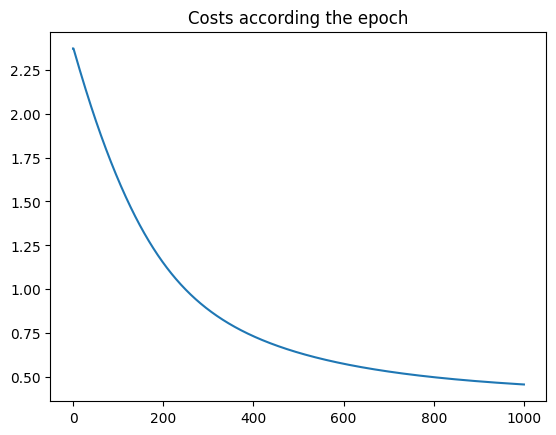

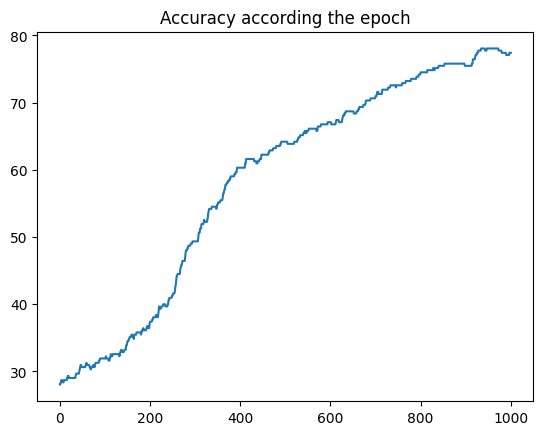

In [ ]:
nepochs = 1000
lr = 0.01

# initial parameter
W = torch.randn((1,13), dtype=torch.double).requires_grad_(True)

# track the costs
costs = [cost(X,Y,W).item()]
accs = [accuracy(Y,predict(X,W))]

# YOUR CODE (START)
for epoch in range(nepochs):
    c = cost(X,Y,W)
    costs.append(c.item())
    c.backward()
    with torch.no_grad():
        W -= lr * W.grad
    W.grad.zero_()
    accs.append(accuracy(Y,predict(X,W)))
# YOUR CODE (END)

accs = np.array(accs)

print("Training Accuracy (max,end): %f, %f"%(np.max(accs), accs[-1]))
print("Training Cost (end): %f"%costs[-1])
plt.figure(1)
plt.plot(range(nepochs+1),costs)
plt.title("Costs according the epoch")
plt.figure(2)
plt.plot(range(nepochs+1),accs)
plt.title("Accuracy according the epoch")

    - Third case : lr = 10

    Now, the learning rate is far too high. The thick lines shows us that the algorithms is struggling to converge. We wasted a lot of calculus ressources.

Training Accuracy (max,end): 84.193548, 83.870968
Training Cost (end): 0.413963


Text(0.5, 1.0, 'Accuracy according the epoch')

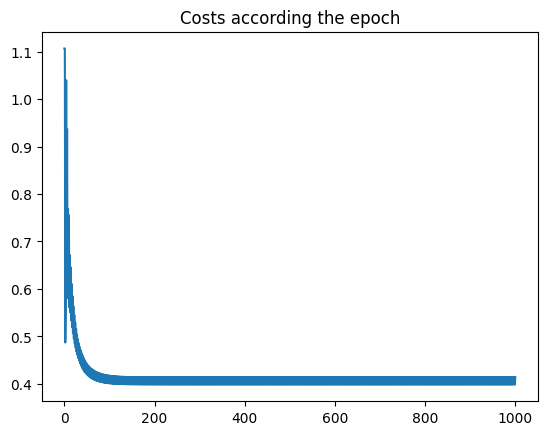

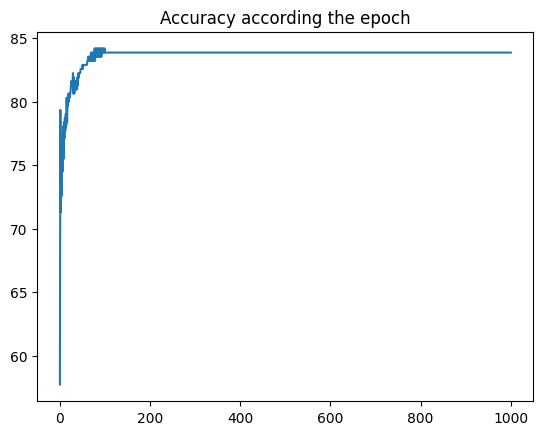

In [ ]:
nepochs = 1000
lr = 10

# initial parameter
W = torch.randn((1,13), dtype=torch.double).requires_grad_(True)

# track the costs
costs = [cost(X,Y,W).item()]
accs = [accuracy(Y,predict(X,W))]

# YOUR CODE (START)
for epoch in range(nepochs):
    c = cost(X,Y,W)
    costs.append(c.item())
    c.backward()
    with torch.no_grad():
        W -= lr * W.grad
    W.grad.zero_()
    accs.append(accuracy(Y,predict(X,W)))
# YOUR CODE (END)

accs = np.array(accs)

print("Training Accuracy (max,end): %f, %f"%(np.max(accs), accs[-1]))
print("Training Cost (end): %f"%costs[-1])
plt.figure(1)
plt.plot(range(nepochs+1),costs)
plt.title("Costs according the epoch")
plt.figure(2)
plt.plot(range(nepochs+1),accs)
plt.title("Accuracy according the epoch")